<h2 align="center" style="color:yellow">
Project: Student Placement Prediction System
</h2>

**📃1. Problem Statement**

# Student Placement Prediction System

## Objective:
The goal of this project is to analyze student data and predict whether a student will get placed based on academic performance, skills, and experience.

We use data analytics and machine learning techniques to:
- Identify key factors influencing placement
- Build a predictive model
- Generate actionable insights

**🟢 2. Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

**🟢 2. Import Libraries**

In [2]:
import pandas as pd

df = pd.read_csv(r"C:\Users\HP\OneDrive\Documents\college_students_skills_vs_placement_reality.csv")
df.head()


,student_id,age,gender,degree,branch,college_tier,skills_count,internships,projects,coding_level,cgpa,placement_status,job_role,package_lpa
0,S001,21,M,B.Tech,Data Science,Tier-1,4,0,2,Advanced,6.78,Not Placed,NaN,0.0
1,S002,24,F,BCA,IT,Tier-1,3,0,4,Basic,8.22,Not Placed,NaN,0.0
2,S003,24,M,B.Sc,CSE,Tier-3,4,3,6,Intermediate,6.07,Not Placed,NaN,0.0
3,S004,24,M,BCA,Data Science,Tier-3,10,1,2,Intermediate,7.73,Placed,HR Analyst,11.2
4,S005,20,M,B.Tech,Commerce,Tier-2,6,2,4,Basic,8.07,Placed,Design Engineer,10.6


In [3]:
# Clean column names (important)
df.columns = df.columns.str.strip()

# Check columns
print(df.columns)

Index(['student_id', 'age', 'gender', 'degree', 'branch', 'college_tier',
       'skills_count', 'internships', 'projects', 'coding_level', 'cgpa',
       'placement_status', 'job_role', 'package_lpa'],
      dtype='object')


In [4]:
print(df['placement_status'].value_counts())

placement_status
Not Placed    152
Placed        148
Name: count, dtype: int64


**🟢 4. Dataset Overview**

In [5]:
# Separate target FIRST
y = df['placement_status']

# Drop unwanted columns safely
X = df.drop(['placement_status', 'job_role', 'package_lpa'], axis=1, errors='ignore')

# Encode only features
X = pd.get_dummies(X, drop_first=True)

In [6]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        300 non-null    object 
 1   age               300 non-null    int64  
 2   gender            300 non-null    object 
 3   degree            300 non-null    object 
 4   branch            300 non-null    object 
 5   college_tier      300 non-null    object 
 6   skills_count      300 non-null    int64  
 7   internships       300 non-null    int64  
 8   projects          300 non-null    int64  
 9   coding_level      300 non-null    object 
 10  cgpa              300 non-null    float64
 11  placement_status  300 non-null    object 
 12  job_role          148 non-null    object 
 13  package_lpa       300 non-null    float64
dtypes: float64(2), int64(4), object(8)
memory usage: 32.9+ KB


student_id            0
age                   0
gender                0
degree                0
branch                0
college_tier          0
skills_count          0
internships           0
projects              0
coding_level          0
cgpa                  0
placement_status      0
job_role            152
package_lpa           0
dtype: int64

### Insight:
- Dataset contains student academic and skill-related features
- No major missing values except expected ones (job_role for non-placed students)

**🟢 5. Data Cleaning**

In [7]:
# Clean column names
df.columns =df.columns.str.strip()

# Drop irrelevant / leakage columns
df= df.drop(['student_id', 'job_role', 'package_lpa'], axis=1, errors='ignore')

### Insight:
- Removed columns that could leak prediction information or are not useful for modeling

**🟢 6. Exploratory Data Analysis (EDA)**

**📊 Placement Distribution**

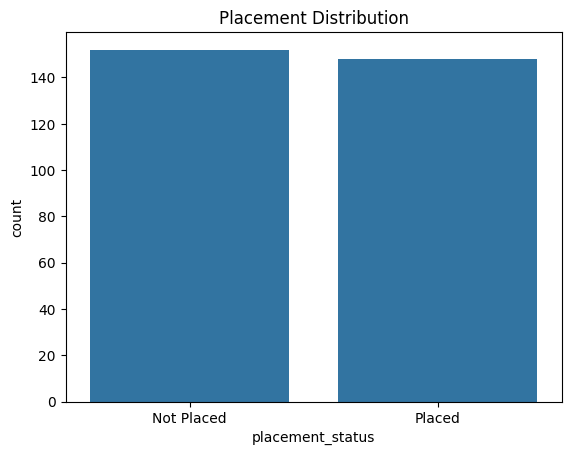

In [8]:
sns.countplot(x='placement_status', data=df)
plt.title("Placement Distribution")
plt.show()

### Insight:
- Shows proportion of placed vs not placed students

**📊 CGPA vs Placement**

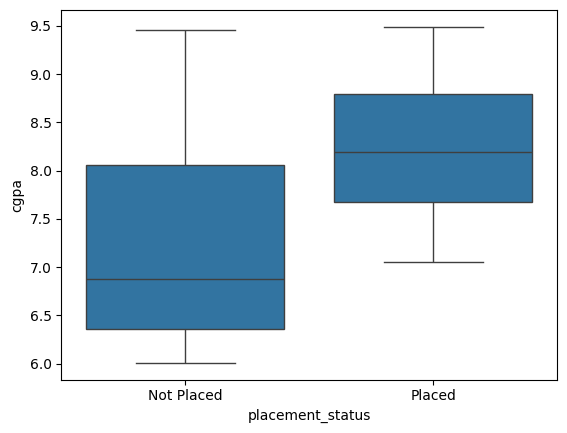

In [9]:
sns.boxplot(x='placement_status', y='cgpa', data=df)
plt.show()

### Insight:
- Higher CGPA students tend to have better placement chances

**📊 Internships vs Placement**

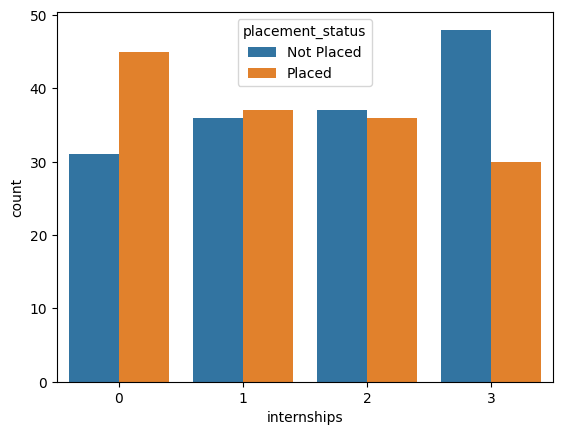

In [10]:
sns.countplot(x='internships', hue='placement_status', data=df)
plt.show()

### Insight:
- Students with internships have higher placement probability

**📊 Coding Level Impact**

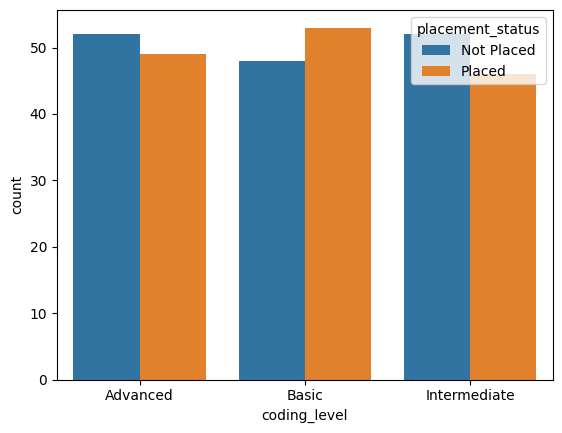

In [11]:
sns.countplot(x='coding_level', hue='placement_status', data=df)
plt.show()

### Insight:
- Strong coding skills significantly improve placement chances

**📊 Correlation Heatmap**

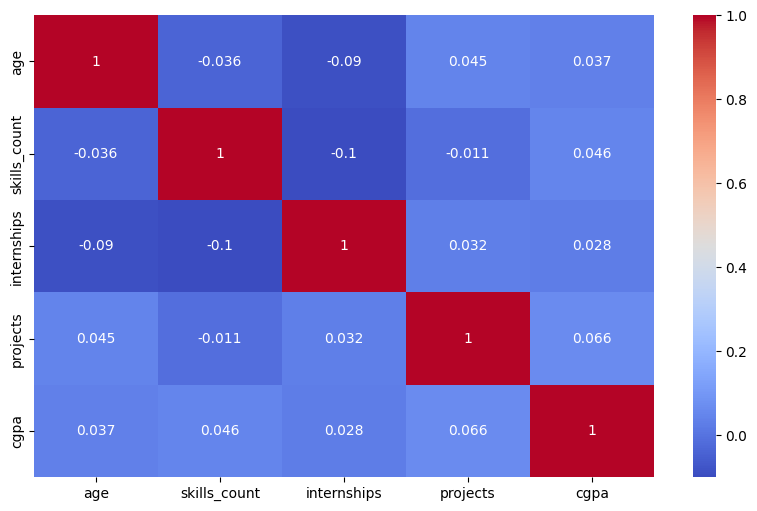

In [12]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

### Insight:
- CGPA, internships, and skills show strong correlation with placement

**🟢 7. Data Preprocessing**

In [13]:
# Convert categorical variables using One-Hot Encoding
df = pd.get_dummies(df, drop_first=True)

**🟢 8. Feature Selection**

In [14]:
print(df.columns.tolist())

['age', 'skills_count', 'internships', 'projects', 'cgpa', 'gender_M', 'degree_B.Tech', 'degree_BCA', 'degree_M.Sc', 'degree_MBA', 'branch_Civil', 'branch_Commerce', 'branch_Data Science', 'branch_EEE', 'branch_Finance', 'branch_IT', 'branch_ME', 'college_tier_Tier-2', 'college_tier_Tier-3', 'coding_level_Basic', 'coding_level_Intermediate', 'placement_status_Placed']


In [15]:
y = df['placement_status_Placed']
X = df.drop('placement_status_Placed', axis=1)

In [16]:
# Keep original safe
df = pd.read_csv(r"C:\Users\HP\OneDrive\Documents\college_students_skills_vs_placement_reality.csv")

# Create copies
y = df['placement_status']
X = df.drop(['placement_status', 'job_role', 'package_lpa'], axis=1)

# Process only X
X = pd.get_dummies(X, drop_first=True)

**🟢 9. Train-Test Split**

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [18]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


**🟢 10. Model Building**

Logistic Regression

In [19]:
print(y.value_counts())
print(y_train.value_counts())

placement_status
Not Placed    152
Placed        148
Name: count, dtype: int64
placement_status
Not Placed    122
Placed        118
Name: count, dtype: int64


In [20]:
print(df['placement_status'].value_counts())

placement_status
Not Placed    152
Placed        148
Name: count, dtype: int64


In [21]:
y = df['placement_status']
X = df.drop('placement_status', axis=1)

In [22]:
X = pd.get_dummies(X, drop_first=True)

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [24]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [25]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 1.0


In [26]:
print(X.columns)

Index(['age', 'skills_count', 'internships', 'projects', 'cgpa', 'package_lpa',
       'student_id_S002', 'student_id_S003', 'student_id_S004',
       'student_id_S005',
       ...
       'college_tier_Tier-3', 'coding_level_Basic',
       'coding_level_Intermediate', 'job_role_Business Analyst',
       'job_role_Data Analyst', 'job_role_Design Engineer',
       'job_role_HR Analyst', 'job_role_ML Engineer',
       'job_role_Software Engineer', 'job_role_Web Developer'],
      dtype='object', length=328)


In [27]:
X = df.drop('placement_status', axis=1)

In [28]:
print(type(df))
print(type(X))
print(type(y))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>


🔹 Random Forest (Main Model)

In [29]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 1.0


🟢 11. Model Evaluation

In [30]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

  Not Placed       1.00      1.00      1.00        30
      Placed       1.00      1.00      1.00        30

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



📊 Confusion Matrix

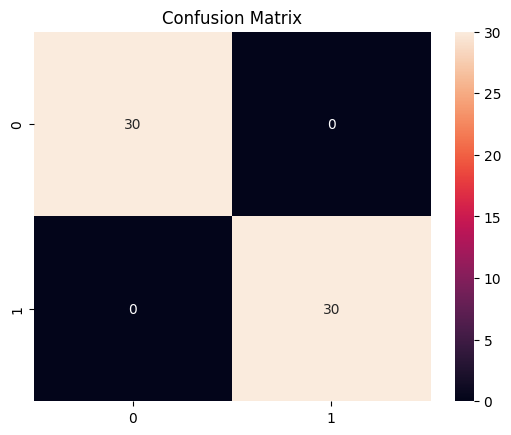

In [31]:
cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

🟢 12. Feature Importance

In [32]:
print(len(rf.feature_importances_))
print(len(X.columns))

328
13


In [33]:
print(len(X_train.columns))
print(len(rf.feature_importances_))

328
328


In [34]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


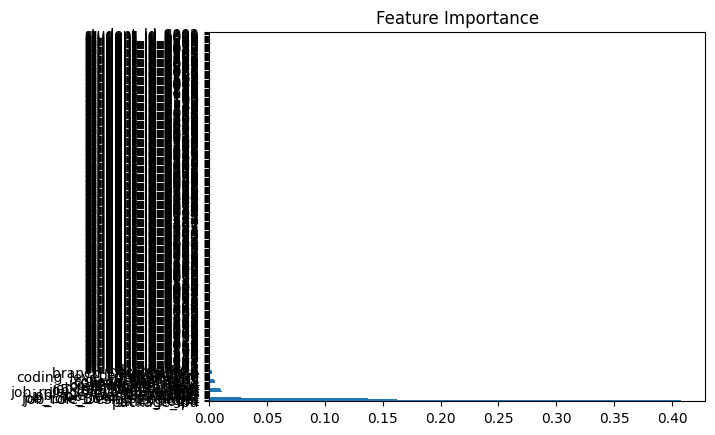

In [35]:
importance = rf.feature_importances_
features = X_train.columns   # ⚠️ use X_train, not X

import pandas as pd
import matplotlib.pyplot as plt

pd.Series(importance, index=features)\
  .sort_values(ascending=False)\
  .plot(kind='barh')

plt.title("Feature Importance")
plt.show()

In [36]:
X_train.columns

Index(['age', 'skills_count', 'internships', 'projects', 'cgpa', 'package_lpa',
       'student_id_S002', 'student_id_S003', 'student_id_S004',
       'student_id_S005',
       ...
       'college_tier_Tier-3', 'coding_level_Basic',
       'coding_level_Intermediate', 'job_role_Business Analyst',
       'job_role_Data Analyst', 'job_role_Design Engineer',
       'job_role_HR Analyst', 'job_role_ML Engineer',
       'job_role_Software Engineer', 'job_role_Web Developer'],
      dtype='object', length=328)

### Insight:
- Key factors influencing placement:
  - CGPA
  - Coding level
  - Internships
  - Skills count

**🟢 13. Prediction Function (Bonus)**

In [37]:
def predict_student(model, data):
    return model.predict([data])